In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/foresight_project'
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Ready:", DRIVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready: /content/drive/MyDrive/foresight_project


In [4]:
!pip install -q kaggle

from google.colab import files
print("Click 'Choose Files' and select the kaggle.json you downloaded earlier:")
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle key installed.")

Click 'Choose Files' and select the kaggle.json you downloaded earlier:


Saving kaggle API KEY.json to kaggle API KEY.json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle key installed.


In [5]:
%cd {DRIVE_DIR}

!kaggle datasets download -d mrayyanshehzad/synthetic-retail-dataset-10-million-transactions
!unzip -q *.zip -d retail_data
print("Done unzipping.")

/content/drive/MyDrive/foresight_project
Dataset URL: https://www.kaggle.com/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions
License(s): apache-2.0
synthetic-retail-dataset-10-million-transactions.zip: Skipping, found more recently modified local copy (use --force to force download)
replace retail_data/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Done unzipping.


In [6]:
!find retail_data -maxdepth 2 -type d
print("---")
!find retail_data -name "*.csv" | sort


retail_data
retail_data/retail_clean_dataset
retail_data/retail_contaminated_dataset
---
retail_data/retail_clean_dataset/customer_master.csv
retail_data/retail_clean_dataset/inventory_snapshot.csv
retail_data/retail_clean_dataset/promotions.csv
retail_data/retail_clean_dataset/sales_transactions.csv
retail_data/retail_clean_dataset/sku_inventory_flags.csv
retail_data/retail_clean_dataset/sku_master.csv
retail_data/retail_clean_dataset/store_master.csv
retail_data/retail_contaminated_dataset/customer_master.csv
retail_data/retail_contaminated_dataset/inventory_snapshot.csv
retail_data/retail_contaminated_dataset/promotions.csv
retail_data/retail_contaminated_dataset/sales_transactions.csv
retail_data/retail_contaminated_dataset/sku_inventory_flags.csv
retail_data/retail_contaminated_dataset/sku_master.csv
retail_data/retail_contaminated_dataset/store_master.csv


In [7]:
CLEAN_DIR = f"{DRIVE_DIR}/retail_data/retail_clean_dataset"
CONTAMINATED_DIR = f"{DRIVE_DIR}/retail_data/retail_contaminated_dataset"

import os
print("Clean folder files:", os.listdir(CLEAN_DIR))
print("Contaminated folder files:", os.listdir(CONTAMINATED_DIR))

Clean folder files: ['sales_transactions.csv', 'promotions.csv', 'customer_master.csv', 'inventory_snapshot.csv', 'store_master.csv', 'sku_inventory_flags.csv', 'sku_master.csv']
Contaminated folder files: ['sales_transactions.csv', 'promotions.csv', 'customer_master.csv', 'inventory_snapshot.csv', 'sku_master.csv', 'sku_inventory_flags.csv', 'store_master.csv']


In [8]:
import pandas as pd

sku_master = pd.read_csv(f"{CONTAMINATED_DIR}/sku_master.csv")

print("Shape (rows, columns):", sku_master.shape)
print()
print("First 5 rows:")
sku_master.head()

Shape (rows, columns): (5000, 7)

First 5 rows:


,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
0,SKU00001,NutriPlus Cookware Large,Home & Kitchen,Cookware,813.41,619.77,NutriPlus
1,SKU00002,CrispKing Bread Family Pack,Dairy & Bakery,Bread,70.38,49.57,CrispKing
2,SKU00003,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,151.28,83.67,SoftTouch
3,SKU00004,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,233.64,156.32,SunriseFoods
4,SKU00005,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,138.50,83.46,SunriseFoods


In [9]:
store_master = pd.read_csv(f"{CONTAMINATED_DIR}/store_master.csv")
print("Shape:", store_master.shape)
store_master.head()

Shape: (30, 5)


,store_id,store_name,city,store_type,opening_date
0,ST01,Quetta Convenience Store #01,Quetta,Convenience Store,2017-07-08
1,ST02,Islamabad Express Store #02,Islamabad,Express Store,2019-05-08
2,ST03,Sialkot Supermarket #03,Sialkot,Supermarket,2019-03-28
3,ST04,Multan Supermarket #04,Multan,Supermarket,2017-10-08
4,ST05,Karachi Supermarket #05,Karachi,Supermarket,2020-11-03


In [10]:
customer_master = pd.read_csv(f"{CONTAMINATED_DIR}/customer_master.csv")
print("Shape:", customer_master.shape)
customer_master.head()

Shape: (10000, 7)


,cust_id,age,gender,city,loyalty_segment,preferred_channel,registration_date
0,CUST00001,52,Female,Sukkur,Silver,Online,2021-01-01
1,CUST00002,41,Female,Karachi,Silver,Mobile App,2021-05-14
2,CUST00003,48,Female,Bahawalpur,Bronze,In-Store,2022-10-23
3,CUST00004,45,Male,Karachi,Silver,In-Store,2015-07-15
4,CUST00005,39,Female,Faisalabad,Bronze,In-Store,2024-01-02


In [11]:
promotions = pd.read_csv(f"{CONTAMINATED_DIR}/promotions.csv")
print("Shape:", promotions.shape)
promotions.head()

Shape: (100, 8)


,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
0,PROMO001,Spring Discount Days,2024-07-28,2024-08-02,15.1,BOGO,Brand,NovaFresh
1,PROMO002,Summer Savings Event,2023-03-09,2023-03-21,7.0,Bundle Offer,All,All
2,PROMO003,Payday Discount Days,2025-04-30,2025-05-26,10.2,BOGO,Brand,ZestyCo
3,PROMO004,Super Sale,2025-06-07,2025-06-17,15.9,Clearance,SKU,SKU01108
4,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,Bundle Offer,All,All


In [12]:
inventory_snapshot = pd.read_csv(f"{CONTAMINATED_DIR}/inventory_snapshot.csv")
print("Shape:", inventory_snapshot.shape)
inventory_snapshot.head()

Shape: (26408, 6)


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,333,72,22,2025-06-23
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,496,96,34,2025-07-10
3,ST19,SKU02907,109,34,13,2025-08-17
4,ST05,SKU01023,333,97,22,2025-07-12


In [13]:
flags_contaminated = pd.read_csv(f"{CONTAMINATED_DIR}/sku_inventory_flags.csv")
flags_clean = pd.read_csv(f"{CLEAN_DIR}/sku_inventory_flags.csv")

print("Contaminated version shape:", flags_contaminated.shape)
print("Clean version shape:", flags_clean.shape)
print("Are the two files byte-for-byte identical?", flags_contaminated.equals(flags_clean))
flags_contaminated.head()

Contaminated version shape: (600, 6)
Clean version shape: (600, 6)
Are the two files byte-for-byte identical? False


,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU04321,STOCKOUT_RISK,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-11-06,2025-12-03,Top-selling SKU (by observed volume); injected...
1,SKU04596,STOCKOUT_RISK,ST12;ST09;ST21;ST23;ST07;ST24;ST01;ST28;ST14;S...,2025-10-25,2025-11-06,Top-selling SKU (by observed volume); injected...
2,SKU03727,STOCKOUT_RISK,ST19;ST14;ST28;ST29;ST02;ST07;ST17;ST08;ST05;ST16,2025-11-08,2025-11-29,Top-selling SKU (by observed volume); injected...
3,SKU04154,STOCKOUT_RISK,ST15;ST03;ST30;ST09;ST24;ST19;ST28;ST02;ST07;S...,2025-11-12,2025-11-26,Top-selling SKU (by observed volume); injected...
4,SKU00953,STOCKOUT_RISK,ST09;ST19;ST27;ST20;ST01;ST03;ST11;ST10;ST22;S...,2025-11-29,2025-12-25,Top-selling SKU (by observed volume); injected...


In [14]:
# Row order might just differ even if the content is the same - sort both and retry
fc_sorted = flags_contaminated.sort_values("sku_id").reset_index(drop=True)
fl_sorted = flags_clean.sort_values("sku_id").reset_index(drop=True)

same_after_sorting = fc_sorted.equals(fl_sorted)
print("Identical after sorting by sku_id?", same_after_sorting)

if not same_after_sorting:
    diff_rows = fc_sorted.ne(fl_sorted).any(axis=1)
    print(f"\nRows that actually differ: {diff_rows.sum()} out of {len(fc_sorted)}")
    print("\nContaminated version of those rows:")
    display(fc_sorted[diff_rows].head())
    print("\nClean version of the same rows:")
    display(fl_sorted[diff_rows].head())

Identical after sorting by sku_id? False

Rows that actually differ: 600 out of 600

Contaminated version of those rows:


,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU00002,STOCKOUT_RISK,ST12;ST29;ST16;ST05;ST01;ST04;ST17;ST14;ST22;S...,2025-11-08,2025-12-06,Top-selling SKU (by observed volume); injected...
1,SKU00012,SLOW_MOVER,ST18;ST21;ST08;ST23;ST29;ST26;ST15;ST10;ST02;S...,NaN,NaN,Bottom-selling SKU (by observed volume); injec...
2,SKU00020,STOCKOUT_RISK,ST13;ST22;ST04;ST01;ST15;ST28;ST25;ST11;ST12;S...,2025-11-28,2025-12-22,Top-selling SKU (by observed volume); injected...
3,SKU00032,SLOW_MOVER,ST21;ST03;ST16;ST23;ST08;ST19;ST27;ST18;ST14;S...,NaN,NaN,Bottom-selling SKU (by observed volume); injec...
4,SKU00050,STOCKOUT_RISK,ST07;ST25;ST29;ST06;ST13;ST10;ST04;ST22;ST30;S...,2025-12-17,2025-12-28,Top-selling SKU (by observed volume); injected...



Clean version of the same rows:


,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU00002,STOCKOUT_RISK,ST10;ST08;ST28;ST25;ST09;ST23;ST06;ST13;ST14;S...,2025-11-07,2025-12-04,High-demand SKU; simulated recent stockout win...
1,SKU00020,STOCKOUT_RISK,ST03;ST01;ST19;ST20;ST07;ST02;ST27;ST15;ST28;S...,2025-12-02,2025-12-26,High-demand SKU; simulated recent stockout win...
2,SKU00024,SLOW_MOVER,ST09;ST20;ST10;ST06;ST08;ST15;ST23;ST14;ST13;S...,NaN,NaN,Chronically low-demand SKU; overstocked with a...
3,SKU00050,STOCKOUT_RISK,ST16;ST21;ST20;ST09;ST08;ST27;ST06;ST28;ST13,2025-11-30,2025-12-19,High-demand SKU; simulated recent stockout win...
4,SKU00052,SLOW_MOVER,ST13;ST26;ST06;ST20;ST25;ST10;ST07;ST02;ST28;S...,NaN,NaN,Chronically low-demand SKU; overstocked with a...


In [15]:
# Take the first STOCKOUT_RISK row from the CONTAMINATED flags file and
# confirm those exact sales are genuinely missing from
# retail_contaminated_dataset/sales_transactions.csv

test_row = flags_contaminated[flags_contaminated["flag"] == "STOCKOUT_RISK"].iloc[0]
test_sku = test_row["sku_id"]
test_store = test_row["affected_stores"].split(";")[0].strip()
test_start = pd.to_datetime(test_row["window_start"])
test_end = pd.to_datetime(test_row["window_end"])

print(f"Checking: {test_sku} at store {test_store}, {test_start.date()} to {test_end.date()}")

matches = 0
for chunk in pd.read_csv(
    f"{CONTAMINATED_DIR}/sales_transactions.csv",
    usecols=["date", "store_id", "sku_id"],
    parse_dates=["date"],
    chunksize=1_000_000,
):
    hit = chunk[
        (chunk["sku_id"] == test_sku)
        & (chunk["store_id"] == test_store)
        & (chunk["date"] >= test_start)
        & (chunk["date"] <= test_end)
    ]
    matches += len(hit)

print(f"Sales rows found for that exact SKU/store/window: {matches}")
print("(Should be 0 - that's the whole point of the stockout injection)")

Checking: SKU04321 at store ST22, 2025-11-06 to 2025-12-03
Sales rows found for that exact SKU/store/window: 0
(Should be 0 - that's the whole point of the stockout injection)


In [16]:
tables = {
    "store_master": store_master,
    "sku_master": sku_master,
    "customer_master": customer_master,
    "promotions": promotions,
    "inventory_snapshot": inventory_snapshot,
}
for name, df in tables.items():
    missing = df.isna().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"{name}: {missing} missing values, {duplicates} exact duplicate rows")

skus_in_inventory = set(inventory_snapshot["sku_id"])
skus_in_master = set(sku_master["sku_id"])
print("SKUs in inventory but missing from sku_master:", len(skus_in_inventory - skus_in_master))

stores_in_inventory = set(inventory_snapshot["store_id"])
stores_in_master = set(store_master["store_id"])
print("Stores in inventory but missing from store_master:", len(stores_in_inventory - stores_in_master))

store_master: 0 missing values, 0 exact duplicate rows
sku_master: 0 missing values, 0 exact duplicate rows
customer_master: 0 missing values, 0 exact duplicate rows
promotions: 0 missing values, 0 exact duplicate rows
inventory_snapshot: 0 missing values, 0 exact duplicate rows
SKUs in inventory but missing from sku_master: 0
Stores in inventory but missing from store_master: 0


In [17]:
tiny_example = pd.DataFrame({
    "date":     ["2024-01-01", "2024-01-01", "2024-01-01", "2024-01-02"],
    "sku_id":   ["SKU001",     "SKU001",     "SKU002",     "SKU001"],
    "quantity": [2,            3,            1,            5],
})
print("Before grouping - one row per individual sale:")
display(tiny_example)

tiny_grouped = tiny_example.groupby(["date", "sku_id"])["quantity"].sum().reset_index()
print("\nAfter grouping - one row per date+product, quantities added together:")
display(tiny_grouped)

Before grouping - one row per individual sale:


,date,sku_id,quantity
0,2024-01-01,SKU001,2
1,2024-01-01,SKU001,3
2,2024-01-01,SKU002,1
3,2024-01-02,SKU001,5



After grouping - one row per date+product, quantities added together:


,date,sku_id,quantity
0,2024-01-01,SKU001,5
1,2024-01-01,SKU002,1
2,2024-01-02,SKU001,5


In [18]:
header_check = pd.read_csv(f"{CONTAMINATED_DIR}/sales_transactions.csv", nrows=0)
print("Columns:", list(header_check.columns))

Columns: ['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']


In [19]:
def aggregate_sales_in_chunks(path, chunksize=1_000_000):
    usecols = ["date", "store_id", "sku_id", "quantity", "total_value", "discount_pct", "promo_id"]
    dtype = {
        "store_id": "category",
        "sku_id": "category",
        "quantity": "int32",
        "total_value": "float32",
        "discount_pct": "float32",
        "promo_id": "string",
    }

    chunk_summaries = []
    reader = pd.read_csv(path, usecols=usecols, dtype=dtype, parse_dates=["date"], chunksize=chunksize)

    for i, chunk in enumerate(reader, start=1):
        print(f"  processing chunk {i} ({len(chunk):,} rows)...")
        chunk["discount_x_qty"] = chunk["discount_pct"].fillna(0) * chunk["quantity"]
        chunk["has_promo"] = chunk["promo_id"].notna()

        summary = (
            chunk.groupby(["date", "store_id", "sku_id"], observed=True)
            .agg(
                units_sold=("quantity", "sum"),
                revenue=("total_value", "sum"),
                discount_x_qty=("discount_x_qty", "sum"),
                promo_flag=("has_promo", "max"),
            )
            .reset_index()
        )
        chunk_summaries.append(summary)

    print("Combining all chunk summaries into one table...")
    combined = pd.concat(chunk_summaries, ignore_index=True)

    daily_store_sku = (
        combined.groupby(["date", "store_id", "sku_id"], observed=True)
        .agg(
            units_sold=("units_sold", "sum"),
            revenue=("revenue", "sum"),
            discount_x_qty=("discount_x_qty", "sum"),
            promo_flag=("promo_flag", "max"),
        )
        .reset_index()
    )
    # Average price = total revenue / total units - NOT an average of
    # per-chunk averages, which would quietly give a slightly wrong
    # number. This is a genuinely common mistake worth knowing about.
    daily_store_sku["avg_unit_price"] = daily_store_sku["revenue"] / daily_store_sku["units_sold"]
    daily_store_sku["avg_discount_pct"] = daily_store_sku["discount_x_qty"] / daily_store_sku["units_sold"]
    return daily_store_sku.drop(columns=["discount_x_qty"])


print("Aggregating sales_transactions.csv - reads all ~10 million rows in batches. Expect several minutes.\n")
daily_store_sku = aggregate_sales_in_chunks(f"{CONTAMINATED_DIR}/sales_transactions.csv")

print(f"\nDone. {len(daily_store_sku):,} summary rows (down from ~10 million individual sales).")
daily_store_sku.head()

Aggregating sales_transactions.csv - reads all ~10 million rows in batches. Expect several minutes.

  processing chunk 1 (1,000,000 rows)...
  processing chunk 2 (1,000,000 rows)...
  processing chunk 3 (1,000,000 rows)...
  processing chunk 4 (1,000,000 rows)...
  processing chunk 5 (1,000,000 rows)...
  processing chunk 6 (1,000,000 rows)...
  processing chunk 7 (1,000,000 rows)...
  processing chunk 8 (1,000,000 rows)...
  processing chunk 9 (1,000,000 rows)...
  processing chunk 10 (945,511 rows)...
Combining all chunk summaries into one table...

Done. 8,513,611 summary rows (down from ~10 million individual sales).


,date,store_id,sku_id,units_sold,revenue,promo_flag,avg_unit_price,avg_discount_pct
0,2022-01-01,ST01,SKU00004,1,233.639999,False,233.639999,0.0
1,2022-01-01,ST01,SKU00059,1,122.449997,False,122.449997,0.0
2,2022-01-01,ST01,SKU00099,2,3343.979980,False,1671.989990,0.0
3,2022-01-01,ST01,SKU00130,1,362.179993,False,362.179993,0.0
4,2022-01-01,ST01,SKU00233,4,483.359985,False,120.839996,0.0


In [20]:
!pip install -q pyarrow

import os
PROCESSED_DIR = f"{DRIVE_DIR}/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

daily_store_sku.to_parquet(f"{PROCESSED_DIR}/daily_store_sku_raw.parquet", index=False)

size_mb = os.path.getsize(f"{PROCESSED_DIR}/daily_store_sku_raw.parquet") / 1e6
print(f"Saved {len(daily_store_sku):,} rows -> daily_store_sku_raw.parquet")
print(f"File size: {size_mb:.1f} MB")

Saved 8,513,611 rows -> daily_store_sku_raw.parquet
File size: 57.3 MB


In [21]:
flags_contaminated = pd.read_csv(
    f"{CONTAMINATED_DIR}/sku_inventory_flags.csv",
    parse_dates=["window_start", "window_end"],
)
stockouts = flags_contaminated[flags_contaminated["flag"] == "STOCKOUT_RISK"].copy()
print(f"STOCKOUT_RISK rows to process: {len(stockouts)}")

exploded_rows = []
for _, r in stockouts.iterrows():
    stores = str(r["affected_stores"]).split(";")
    for d in pd.date_range(r["window_start"], r["window_end"], freq="D"):
        for s in stores:
            exploded_rows.append((d, s.strip(), r["sku_id"]))

censored_lookup = pd.DataFrame(exploded_rows, columns=["date", "store_id", "sku_id"]).drop_duplicates()
censored_lookup["is_stockout_censored"] = True
print(f"Exact (date, store, sku) combinations affected: {len(censored_lookup):,}")

daily_store_sku = daily_store_sku.merge(
    censored_lookup, on=["date", "store_id", "sku_id"], how="outer"
)
daily_store_sku["is_stockout_censored"] = daily_store_sku["is_stockout_censored"].fillna(False)
for col in ["units_sold", "revenue"]:
    daily_store_sku[col] = daily_store_sku[col].fillna(0)
daily_store_sku["promo_flag"] = daily_store_sku["promo_flag"].fillna(False)

print(f"\nTotal rows now: {len(daily_store_sku):,}")
print(f"Rows marked stockout-censored: {daily_store_sku['is_stockout_censored'].sum():,}")

STOCKOUT_RISK rows to process: 200
Exact (date, store, sku) combinations affected: 55,327


/tmp/ipykernel_12822/859166251.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_store_sku["is_stockout_censored"] = daily_store_sku["is_stockout_censored"].fillna(False)



Total rows now: 8,568,938
Rows marked stockout-censored: 55,327


/tmp/ipykernel_12822/859166251.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_store_sku["promo_flag"] = daily_store_sku["promo_flag"].fillna(False)


In [22]:
check = daily_store_sku[
    (daily_store_sku["sku_id"] == "SKU04321")
    & (daily_store_sku["store_id"] == "ST22")
    & (daily_store_sku["date"] >= "2025-11-06")
    & (daily_store_sku["date"] <= "2025-12-03")
]
print(f"Rows found: {len(check)} (expect 28 - one per day in that window)")
print(f"All marked censored: {check['is_stockout_censored'].all()}")
check.head()

Rows found: 28 (expect 28 - one per day in that window)
All marked censored: True


,date,store_id,sku_id,units_sold,revenue,promo_flag,avg_unit_price,avg_discount_pct,is_stockout_censored
8107285,2025-11-06,ST22,SKU04321,0.0,0.0,False,NaN,NaN,True
8115183,2025-11-07,ST22,SKU04321,0.0,0.0,False,NaN,NaN,True
8123255,2025-11-08,ST22,SKU04321,0.0,0.0,False,NaN,NaN,True
8131328,2025-11-09,ST22,SKU04321,0.0,0.0,False,NaN,NaN,True
8139272,2025-11-10,ST22,SKU04321,0.0,0.0,False,NaN,NaN,True


In [23]:
daily_store_sku.to_parquet(f"{PROCESSED_DIR}/daily_store_sku.parquet", index=False)
print("Saved.")

Saved.


In [24]:
start_date = daily_store_sku["date"].min()
end_date = daily_store_sku["date"].max()
print(f"Date range: {start_date.date()} to {end_date.date()}")

calendar = pd.DataFrame({"date": pd.date_range(start_date, end_date, freq="D")})
calendar["year"] = calendar["date"].dt.year
calendar["month"] = calendar["date"].dt.month
calendar["week"] = calendar["date"].dt.isocalendar().week.astype(int)
calendar["quarter"] = calendar["date"].dt.quarter
calendar["day_of_week"] = calendar["date"].dt.day_name()
calendar["is_weekend"] = calendar["date"].dt.dayofweek >= 5
calendar["season"] = "regular"
calendar.loc[calendar["month"].isin([11, 12]), "season"] = "peak_nov_dec"
calendar.loc[calendar["month"].isin([1, 2]), "season"] = "trough_jan_feb"

calendar["is_holiday"] = False
fixed_holidays = ["02-05", "03-23", "05-01", "08-14", "11-09", "12-25"]
# Kashmir Day, Pakistan Day, Labour Day, Independence Day, Iqbal Day, Quaid-e-Azam Day.
# Eid ul-Fitr / Eid ul-Adha shift every year on the Islamic calendar and
# aren't included here - a documented limitation, worth a line in your report.
calendar.loc[calendar["date"].dt.strftime("%m-%d").isin(fixed_holidays), "is_holiday"] = True

calendar.to_parquet(f"{PROCESSED_DIR}/calendar.parquet", index=False)
print(f"Calendar table: {len(calendar):,} rows, saved.")
calendar.head()

Date range: 2022-01-01 to 2025-12-31
Calendar table: 1,461 rows, saved.


,date,year,month,week,quarter,day_of_week,is_weekend,season,is_holiday
0,2022-01-01,2022,1,52,1,Saturday,True,trough_jan_feb,False
1,2022-01-02,2022,1,52,1,Sunday,True,trough_jan_feb,False
2,2022-01-03,2022,1,1,1,Monday,False,trough_jan_feb,False
3,2022-01-04,2022,1,1,1,Tuesday,False,trough_jan_feb,False
4,2022-01-05,2022,1,1,1,Wednesday,False,trough_jan_feb,False


In [25]:
daily_store_sku["discount_x_qty"] = daily_store_sku["avg_discount_pct"].fillna(0) * daily_store_sku["units_sold"]

daily_sku = (
    daily_store_sku.groupby(["date", "sku_id"], observed=True)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        discount_x_qty=("discount_x_qty", "sum"),
        promo_flag=("promo_flag", "max"),
        n_stores_censored=("is_stockout_censored", "sum"),
    )
    .reset_index()
)

daily_sku["avg_unit_price"] = daily_sku["revenue"] / daily_sku["units_sold"]
daily_sku["avg_discount_pct"] = daily_sku["discount_x_qty"] / daily_sku["units_sold"]
daily_sku = daily_sku.drop(columns=["discount_x_qty"])

print(f"Chain-level table: {len(daily_sku):,} rows (one per SKU per day)")
daily_sku.head()

Chain-level table: 4,143,581 rows (one per SKU per day)


,date,sku_id,units_sold,revenue,promo_flag,n_stores_censored,avg_unit_price,avg_discount_pct
0,2022-01-01,SKU00002,30.0,2111.399902,False,0,70.379997,0.0
1,2022-01-01,SKU00003,2.0,302.559998,False,0,151.279999,0.0
2,2022-01-01,SKU00004,1.0,233.639999,False,0,233.639999,0.0
3,2022-01-01,SKU00005,8.0,1108.000000,False,0,138.500000,0.0
4,2022-01-01,SKU00006,2.0,2827.840088,False,0,1413.920044,0.0


In [26]:
print("Store-level total units:", f"{daily_store_sku['units_sold'].sum():,.0f}")
print("Chain-level total units:", f"{daily_sku['units_sold'].sum():,.0f}")
print("Store-level total revenue:", f"{daily_store_sku['revenue'].sum():,.2f}")
print("Chain-level total revenue:", f"{daily_sku['revenue'].sum():,.2f}")

Store-level total units: 18,700,906
Chain-level total units: 18,700,906
Store-level total revenue: 10,885,479,424.00
Chain-level total revenue: 10,885,487,616.00


In [27]:
daily_sku.to_parquet(f"{PROCESSED_DIR}/daily_sku.parquet", index=False)
print("Saved daily_sku.parquet")

Saved daily_sku.parquet


In [28]:
import pandas as pd

try:
    daily_sku
    daily_store_sku
    print("Using tables already in memory.")
except NameError:
    print("Session reset since last step - reloading from saved files instead of recomputing...")
    daily_store_sku = pd.read_parquet(f"{PROCESSED_DIR}/daily_store_sku.parquet")
    daily_sku = pd.read_parquet(f"{PROCESSED_DIR}/daily_sku.parquet")
    print("Reloaded.")

sku_master = pd.read_csv(f"{CONTAMINATED_DIR}/sku_master.csv")
store_master = pd.read_csv(f"{CONTAMINATED_DIR}/store_master.csv")
sku_cols = ["sku_id", "category", "subcategory", "brand", "unit_price", "cost_price"]

daily_sku_final = daily_sku.merge(sku_master[sku_cols], on="sku_id", how="left")
daily_store_sku_final = (
    daily_store_sku
    .merge(sku_master[sku_cols], on="sku_id", how="left")
    .merge(store_master[["store_id", "city", "store_type"]], on="store_id", how="left")
)

print(f"\ndaily_sku_final: {daily_sku_final.shape}")
print(f"Unmatched SKUs (should be 0): {daily_sku_final['category'].isna().sum()}")
print(f"\ndaily_store_sku_final: {daily_store_sku_final.shape}")
print(f"Unmatched rows (should be 0): {daily_store_sku_final[['category','city']].isna().any(axis=1).sum()}")
daily_sku_final.head()

Using tables already in memory.

daily_sku_final: (4143581, 13)
Unmatched SKUs (should be 0): 0

daily_store_sku_final: (8568938, 17)
Unmatched rows (should be 0): 0


,date,sku_id,units_sold,revenue,promo_flag,n_stores_censored,avg_unit_price,avg_discount_pct,category,subcategory,brand,unit_price,cost_price
0,2022-01-01,SKU00002,30.0,2111.399902,False,0,70.379997,0.0,Dairy & Bakery,Bread,CrispKing,70.38,49.57
1,2022-01-01,SKU00003,2.0,302.559998,False,0,151.279999,0.0,Stationery & Office,Notebooks,SoftTouch,151.28,83.67
2,2022-01-01,SKU00004,1.0,233.639999,False,0,233.639999,0.0,Dairy & Bakery,Eggs,SunriseFoods,233.64,156.32
3,2022-01-01,SKU00005,8.0,1108.000000,False,0,138.500000,0.0,Home Care,Pest Control,SunriseFoods,138.50,83.46
4,2022-01-01,SKU00006,2.0,2827.840088,False,0,1413.920044,0.0,Health & Wellness,OTC Medicine,UrbanBite,1413.92,830.81


In [29]:
daily_sku_final.to_parquet(f"{PROCESSED_DIR}/daily_sku_final.parquet", index=False)
daily_store_sku_final.to_parquet(f"{PROCESSED_DIR}/daily_store_sku_final.parquet", index=False)

print("WEEK 1 PIPELINE - FINAL SUMMARY")
print("="*50)
print(f"daily_sku_final:        {len(daily_sku_final):,} rows")
print(f"daily_store_sku_final:  {len(daily_store_sku_final):,} rows")
print(f"Date range:             {daily_sku_final['date'].min().date()} -> {daily_sku_final['date'].max().date()}")
print(f"Unique SKUs:            {daily_sku_final['sku_id'].nunique():,}")
print(f"Stockout-censored rows: {daily_store_sku_final['is_stockout_censored'].sum():,}")
print("="*50)
!ls -la "{PROCESSED_DIR}"

WEEK 1 PIPELINE - FINAL SUMMARY
daily_sku_final:        4,143,581 rows
daily_store_sku_final:  8,568,938 rows
Date range:             2022-01-01 -> 2025-12-31
Unique SKUs:            5,000
Stockout-censored rows: 55,327
total 326331
-rw------- 1 root root     18778 Aug 30 05:53 calendar.parquet
-rw------- 1 root root  57525442 Aug 30 05:54 daily_sku_final.parquet
-rw------- 1 root root  36045981 Aug 30 05:53 daily_sku.parquet
-rw------- 1 root root 104406180 Aug 30 05:54 daily_store_sku_final.parquet
-rw------- 1 root root  57841411 Aug 30 05:53 daily_store_sku.parquet
-rw------- 1 root root  57331845 Aug 30 05:52 daily_store_sku_raw.parquet
-rw------- 1 root root    857716 Aug 28 15:37 demand_forecast_model.pkl
-rw------- 1 root root    238748 Aug 28 15:37 risk_scores.parquet
-rw------- 1 root root  19893410 Aug 22 18:11 weekly_sku_features.parquet


In [30]:
import pandas as pd
import os

DRIVE_DIR = '/content/drive/MyDrive/foresight_project'
PROCESSED_DIR = f"{DRIVE_DIR}/processed"

print("WEEK 1 COMPLETION CHECK")
print("="*60)

required_files = ["daily_sku_final.parquet", "daily_store_sku_final.parquet", "calendar.parquet"]
missing = [f for f in required_files if not os.path.exists(f"{PROCESSED_DIR}/{f}")]

if missing:
    print("Missing files - re-run the step that creates each of these:")
    for f in missing:
        print(f"  X {f}")
else:
    daily_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_sku_final.parquet")
    daily_store_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_store_sku_final.parquet")
    calendar = pd.read_parquet(f"{PROCESSED_DIR}/calendar.parquet")

    print(f"daily_sku_final:       {len(daily_sku_final):,} rows, {daily_sku_final['sku_id'].nunique():,} unique SKUs")
    print(f"daily_store_sku_final: {len(daily_store_sku_final):,} rows")
    print(f"calendar:              {len(calendar):,} rows ({calendar['date'].min().date()} to {calendar['date'].max().date()})")

    store_units = daily_store_sku_final['units_sold'].sum()
    chain_units = daily_sku_final['units_sold'].sum()
    store_revenue = daily_store_sku_final['revenue'].sum()
    chain_revenue = daily_sku_final['revenue'].sum()
    units_match = abs(store_units - chain_units) < 1
    revenue_match = abs(store_revenue - chain_revenue) < 1

    print(f"\nRollup check - units:   store-level {store_units:,.0f} vs chain-level {chain_units:,.0f} -> match: {units_match}")
    print(f"Rollup check - revenue: store-level Rs.{store_revenue:,.0f} vs chain-level Rs.{chain_revenue:,.0f} -> match: {revenue_match}")

    unmatched_sku = daily_sku_final['category'].isna().sum()
    unmatched_row = daily_store_sku_final[['category', 'city']].isna().any(axis=1).sum()
    print(f"\nUnmatched SKUs after merge (want 0): {unmatched_sku}")
    print(f"Unmatched rows after merge (want 0): {unmatched_row}")

    n_censored = daily_store_sku_final['is_stockout_censored'].sum()
    print(f"\nStockout-censored rows tagged (want 55,327): {n_censored:,}")

    all_good = units_match and revenue_match and unmatched_sku == 0 and unmatched_row == 0 and n_censored == 55327

    print("\n" + "="*60)
    print("ALL CHECKS PASSED - Week 1 is confirmed complete." if all_good else "Something above doesn't match expected - paste this output back.")
    print("="*60)

WEEK 1 COMPLETION CHECK
daily_sku_final:       4,143,581 rows, 5,000 unique SKUs
daily_store_sku_final: 8,568,938 rows
calendar:              1,461 rows (2022-01-01 to 2025-12-31)

Rollup check - units:   store-level 18,700,906 vs chain-level 18,700,906 -> match: True
Rollup check - revenue: store-level Rs.10,885,479,424 vs chain-level Rs.10,885,487,616 -> match: False

Unmatched SKUs after merge (want 0): 0
Unmatched rows after merge (want 0): 0

Stockout-censored rows tagged (want 55,327): 55,327

Something above doesn't match expected - paste this output back.


In [31]:
import pandas as pd
import os

DRIVE_DIR = '/content/drive/MyDrive/foresight_project'
PROCESSED_DIR = f"{DRIVE_DIR}/processed"

required_files = ["daily_sku_final.parquet", "daily_store_sku_final.parquet", "calendar.parquet"]
missing = [f for f in required_files if not os.path.exists(f"{PROCESSED_DIR}/{f}")]

if missing:
    print("Missing files:", missing)
else:
    daily_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_sku_final.parquet")
    daily_store_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_store_sku_final.parquet")
    calendar = pd.read_parquet(f"{PROCESSED_DIR}/calendar.parquet")

    units_match = abs(daily_store_sku_final['units_sold'].sum() - daily_sku_final['units_sold'].sum()) < 1
    revenue_match = abs(daily_store_sku_final['revenue'].sum() - daily_sku_final['revenue'].sum()) < 1
    unmatched = daily_sku_final['category'].isna().sum()
    n_censored = daily_store_sku_final['is_stockout_censored'].sum()

    print(f"Rows match after rollup: {units_match and revenue_match}")
    print(f"Unmatched SKUs (want 0): {unmatched}")
    print(f"Censored rows tagged (want 55,327): {n_censored:,}")
    print("WEEK 1 CONFIRMED COMPLETE" if (units_match and revenue_match and unmatched == 0 and n_censored == 55327) else "Mismatch above - paste this back")

Rows match after rollup: False
Unmatched SKUs (want 0): 0
Censored rows tagged (want 55,327): 55,327
Mismatch above - paste this back


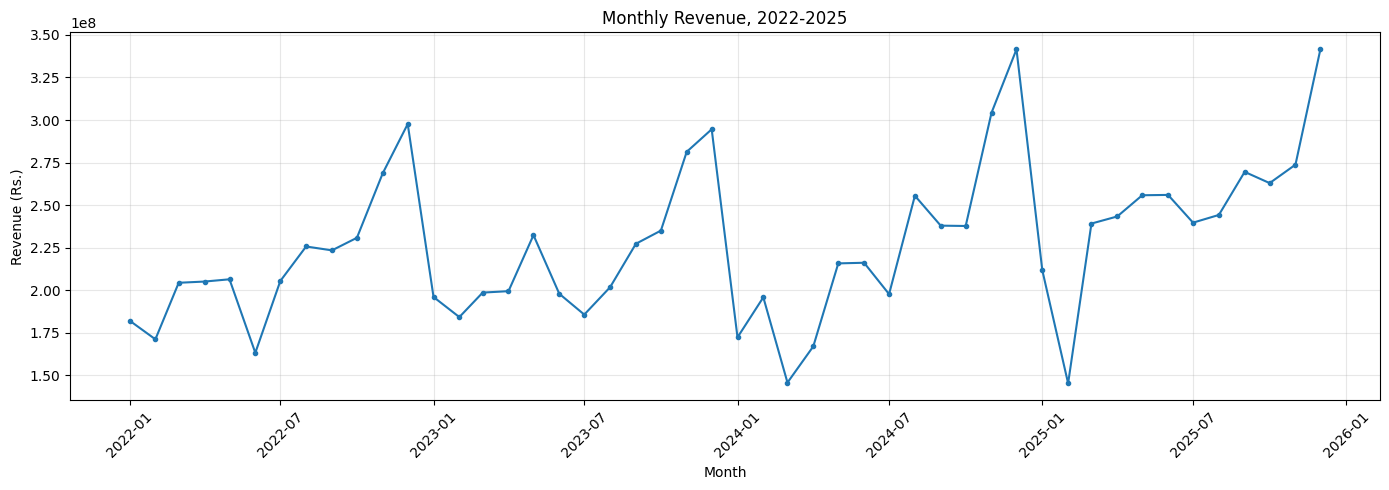

     month     revenue  units_sold
2022-01-01 182039520.0    299649.0
2022-02-01 171043536.0    279983.0
2022-03-01 204283312.0    332417.0
2022-04-01 205001280.0    330560.0
2022-05-01 206328512.0    351452.0
2022-06-01 163097712.0    352922.0
2022-07-01 205324592.0    333342.0
2022-08-01 225620704.0    367973.0
2022-09-01 223342160.0    367848.0
2022-10-01 230738128.0    370513.0
2022-11-01 268673632.0    435675.0
2022-12-01 297634048.0    488850.0
2023-01-01 195915472.0    317227.0
2023-02-01 184107024.0    297894.0
2023-03-01 198506720.0    352208.0
2023-04-01 199349552.0    351468.0
2023-05-01 232307744.0    373341.0
2023-06-01 197811744.0    371584.0
2023-07-01 185577040.0    349505.0
2023-08-01 201670912.0    393054.0
2023-09-01 227218944.0    391708.0
2023-10-01 234962928.0    391602.0
2023-11-01 281293952.0    465696.0
2023-12-01 294543840.0    518586.0
2024-01-01 172190112.0    334790.0
2024-02-01 195735216.0    316128.0
2024-03-01 145588864.0    370495.0
2024-04-01 166877216

In [32]:
import matplotlib.pyplot as plt

daily_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_sku_final.parquet")

monthly = (
    daily_sku_final
    .assign(month=daily_sku_final["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(revenue=("revenue", "sum"), units_sold=("units_sold", "sum"))
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly["month"], monthly["revenue"], marker="o", markersize=3)
plt.title("Monthly Revenue, 2022-2025")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(monthly.to_string(index=False))

In [33]:
def close_enough(a, b, tol=1e-4):
    # True if a and b agree to within 0.01% of their size, rather than
    # within a fixed number - appropriate for float32 totals in the
    # hundreds of millions, where "off by a few dozen" is expected noise,
    # not an error.
    return abs(a - b) <= tol * max(abs(a), abs(b))

store_units = daily_store_sku_final['units_sold'].sum()
chain_units = daily_sku_final['units_sold'].sum()
store_revenue = daily_store_sku_final['revenue'].sum()
chain_revenue = daily_sku_final['revenue'].sum()

print(f"Units   - store: {store_units:,.2f}  chain: {chain_units:,.2f}  diff: {abs(store_units-chain_units):,.4f}")
print(f"Revenue - store: {store_revenue:,.2f}  chain: {chain_revenue:,.2f}  diff: {abs(store_revenue-chain_revenue):,.4f}")

units_match = close_enough(store_units, chain_units)
revenue_match = close_enough(store_revenue, chain_revenue)
unmatched = daily_sku_final['category'].isna().sum()
n_censored = daily_store_sku_final['is_stockout_censored'].sum()

print(f"\nUnits match (within 0.01%):   {units_match}")
print(f"Revenue match (within 0.01%): {revenue_match}")
print(f"Unmatched SKUs (want 0):      {unmatched}")
print(f"Censored rows (want 55,327):  {n_censored:,}")

all_good = units_match and revenue_match and unmatched == 0 and n_censored == 55327
print("\nWEEK 1 CONFIRMED COMPLETE" if all_good else "Still off - paste this output back")

Units   - store: 18,700,906.00  chain: 18,700,906.00  diff: 0.0000
Revenue - store: 10,885,479,424.00  chain: 10,885,487,616.00  diff: 8,192.0000

Units match (within 0.01%):   True
Revenue match (within 0.01%): True
Unmatched SKUs (want 0):      0
Censored rows (want 55,327):  55,327

WEEK 1 CONFIRMED COMPLETE


In [34]:
yearly = daily_sku_final.assign(year=daily_sku_final["date"].dt.year).groupby("year")["revenue"].sum()
print(yearly)
print("\nYear-over-year growth %:")
print((yearly.pct_change() * 100).round(1))

year
2022    2.583127e+09
2023    2.633266e+09
2024    2.686557e+09
2025    2.982529e+09
Name: revenue, dtype: float32

Year-over-year growth %:
year
2022     NaN
2023     1.9
2024     2.0
2025    11.0
Name: revenue, dtype: float32


Top 20% of SKUs (1,000 of 5,000) generate 73.1% of total revenue


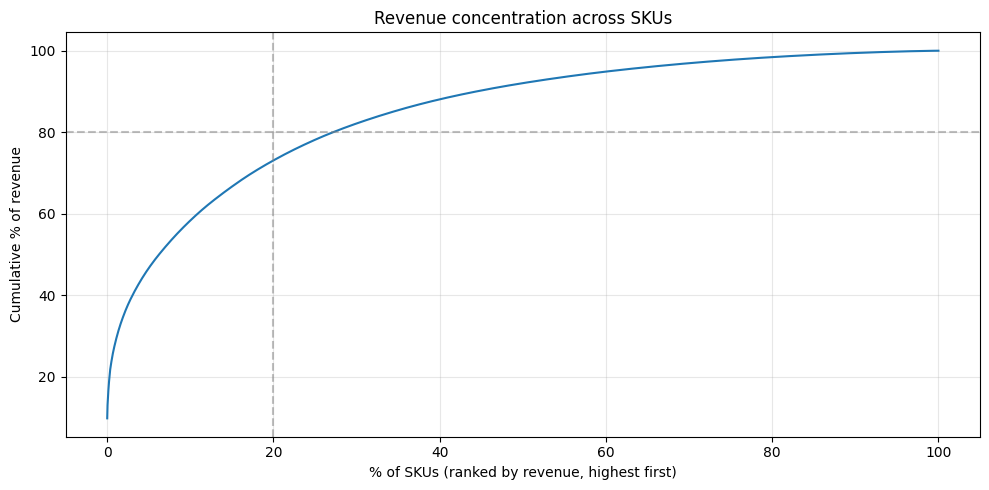


Top 10 SKUs by revenue:
  sku_id  total_revenue  total_units
SKU04321   1069036224.0    1186104.0
SKU03727    259944992.0     166840.0
SKU04329     94199968.0      41153.0
SKU04596     88813536.0     283431.0
SKU03053     83545376.0      21787.0
SKU01371     83124552.0      69864.0
SKU01189     69426384.0      32183.0
SKU04551     68791176.0      29679.0
SKU04157     68736424.0      27308.0
SKU04571     62182280.0      75939.0

Bottom 10 SKUs by revenue:
  sku_id  total_revenue  total_units
SKU03139   49099.351562       1310.0
SKU01944   44714.332031       1312.0
SKU03871   43355.718750       1328.0
SKU00764   43327.191406       1471.0
SKU03593   43066.140625       1790.0
SKU00585   41873.328125       1277.0
SKU03533   41629.769531       1329.0
SKU04054   39570.511719       1218.0
SKU04231   35979.628906       1514.0
SKU03291   33021.218750       1210.0


In [35]:
sku_totals = (
    daily_sku_final.groupby("sku_id", observed=True)
    .agg(total_revenue=("revenue", "sum"), total_units=("units_sold", "sum"))
    .reset_index()
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)
sku_totals["cumulative_revenue_pct"] = sku_totals["total_revenue"].cumsum() / sku_totals["total_revenue"].sum() * 100
sku_totals["sku_rank_pct"] = (sku_totals.index + 1) / len(sku_totals) * 100

top20_share = sku_totals[sku_totals["sku_rank_pct"] <= 20]["cumulative_revenue_pct"].max()
print(f"Top 20% of SKUs ({int(len(sku_totals)*0.2):,} of {len(sku_totals):,}) generate {top20_share:.1f}% of total revenue")

plt.figure(figsize=(10, 5))
plt.plot(sku_totals["sku_rank_pct"], sku_totals["cumulative_revenue_pct"])
plt.axvline(20, color="gray", linestyle="--", alpha=0.5)
plt.axhline(80, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("% of SKUs (ranked by revenue, highest first)")
plt.ylabel("Cumulative % of revenue")
plt.title("Revenue concentration across SKUs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 SKUs by revenue:")
print(sku_totals.head(10)[["sku_id", "total_revenue", "total_units"]].to_string(index=False))
print("\nBottom 10 SKUs by revenue:")
print(sku_totals.tail(10)[["sku_id", "total_revenue", "total_units"]].to_string(index=False))

In [36]:
flags_contaminated = pd.read_csv(f"{CONTAMINATED_DIR}/sku_inventory_flags.csv")
stockout_skus = set(flags_contaminated[flags_contaminated["flag"] == "STOCKOUT_RISK"]["sku_id"])
slowmover_skus = set(flags_contaminated[flags_contaminated["flag"] == "SLOW_MOVER"]["sku_id"])

sku_totals["flag_type"] = "unflagged"
sku_totals.loc[sku_totals["sku_id"].isin(stockout_skus), "flag_type"] = "STOCKOUT_RISK"
sku_totals.loc[sku_totals["sku_id"].isin(slowmover_skus), "flag_type"] = "SLOW_MOVER"

print("Average revenue-rank percentile by flag (closer to 0% = bestseller, closer to 100% = worst seller):")
print(sku_totals.groupby("flag_type")["sku_rank_pct"].mean().round(1))

Average revenue-rank percentile by flag (closer to 0% = bestseller, closer to 100% = worst seller):
flag_type
SLOW_MOVER       65.1
STOCKOUT_RISK    11.6
unflagged        50.4
Name: sku_rank_pct, dtype: float64


In [37]:
cagr = (yearly[2025] / yearly[2022]) ** (1/3) - 1
print(f"Compound annual growth rate, 2022 -> 2025: {cagr*100:.1f}%")

Compound annual growth rate, 2022 -> 2025: 4.9%


In [38]:
monthly_by_year = (
    daily_sku_final
    .assign(year=daily_sku_final["date"].dt.year, month=daily_sku_final["date"].dt.month)
    .groupby(["year", "month"])["revenue"]
    .sum()
    .unstack("month")
)
print(monthly_by_year.round(0))

print("\nLowest-revenue month each year:")
print(monthly_by_year.idxmin(axis=1))
print("\nHighest-revenue month each year:")
print(monthly_by_year.idxmax(axis=1))

month           1            2            3            4            5   \
year                                                                     
2022   182039520.0  171043536.0  204283312.0  205001280.0  206328512.0   
2023   195915472.0  184107024.0  198506720.0  199349552.0  232307744.0   
2024   172190112.0  195735216.0  145588864.0  166877216.0  215685408.0   
2025   211642944.0  145135200.0  239105760.0  243282688.0  255747696.0   

month           6            7            8            9            10  \
year                                                                     
2022   163097712.0  205324592.0  225620704.0  223342160.0  230738128.0   
2023   197811744.0  185577040.0  201670912.0  227218944.0  234962928.0   
2024   216055696.0  197607408.0  255468688.0  237878240.0  237680768.0   
2025   255948240.0  239634752.0  244167632.0  269496064.0  262898560.0   

month           11           12  
year                             
2022   268673632.0  297634048.0  
2023   2

In [39]:
sku_totals["units_rank_pct"] = sku_totals["total_units"].rank(ascending=False, pct=True) * 100
print(sku_totals.groupby("flag_type")[["sku_rank_pct", "units_rank_pct"]].mean().round(1))

               sku_rank_pct  units_rank_pct
flag_type                                  
SLOW_MOVER             65.1            96.0
STOCKOUT_RISK          11.6             2.0
unflagged              50.4            48.0


SKUs with both promo and non-promo days: 5,000 of 5,000
Median lift in units sold on promo days: -2.0%
SKUs that sell MORE on promo days: 36.4%


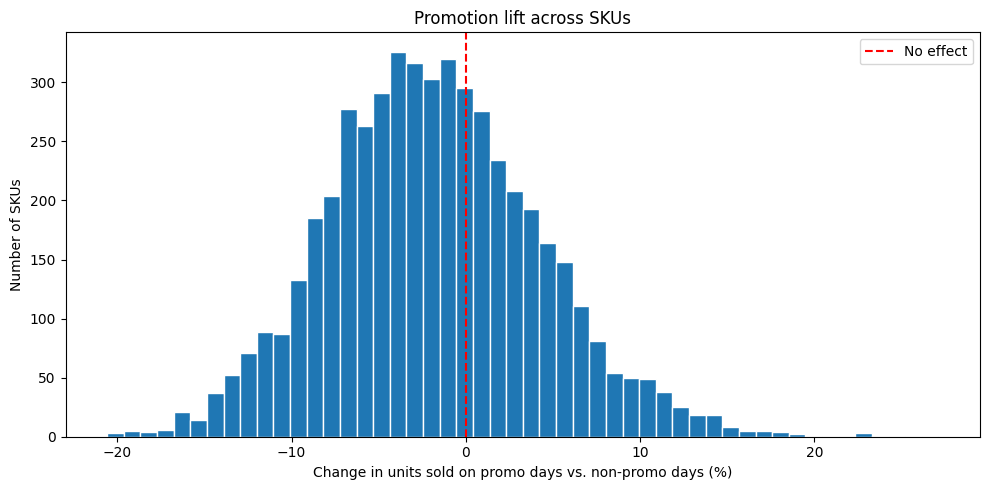

In [40]:
promo_effect = (
    daily_sku_final
    .groupby(["sku_id", "promo_flag"], observed=True)["units_sold"]
    .mean()
    .unstack("promo_flag")
)
promo_effect = promo_effect.rename(columns={True: "avg_units_promo", False: "avg_units_no_promo"}).dropna()
promo_effect["lift_pct"] = (promo_effect["avg_units_promo"] / promo_effect["avg_units_no_promo"] - 1) * 100

print(f"SKUs with both promo and non-promo days: {len(promo_effect):,} of {daily_sku_final['sku_id'].nunique():,}")
print(f"Median lift in units sold on promo days: {promo_effect['lift_pct'].median():.1f}%")
print(f"SKUs that sell MORE on promo days: {(promo_effect['lift_pct'] > 0).mean()*100:.1f}%")

plt.figure(figsize=(10, 5))
plt.hist(promo_effect["lift_pct"].clip(-100, 300), bins=50, edgecolor="white")
plt.axvline(0, color="red", linestyle="--", label="No effect")
plt.xlabel("Change in units sold on promo days vs. non-promo days (%)")
plt.ylabel("Number of SKUs")
plt.title("Promotion lift across SKUs")
plt.legend()
plt.tight_layout()
plt.show()

                 category  total_revenue  total_units  revenue_share_pct
Electronics & Accessories   2328292096.0    1378400.0          21.388969
       Apparel & Footwear   1911953664.0    1224134.0          17.564257
            Personal Care   1618258304.0    2704996.0          14.866209
           Home & Kitchen   1578784256.0    1402335.0          14.503579
        Health & Wellness    888955776.0    1255311.0           8.166436
             Frozen Foods    813617280.0    1548577.0           7.474335
                Home Care    422098080.0    1553994.0           3.877625
           Dairy & Bakery    351111648.0    1718591.0           3.225504
                  Grocery    349330144.0    1491246.0           3.209139
      Stationery & Office    309395264.0    1742469.0           2.842275
                Beverages    180876224.0    1417063.0           1.661628
   Snacks & Confectionery    132806520.0    1263790.0           1.220034


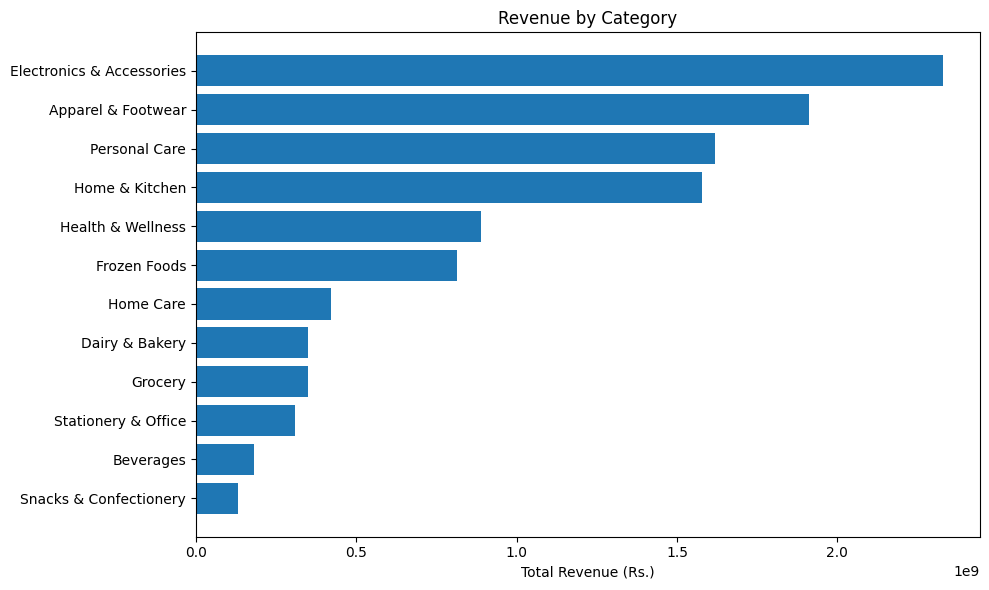

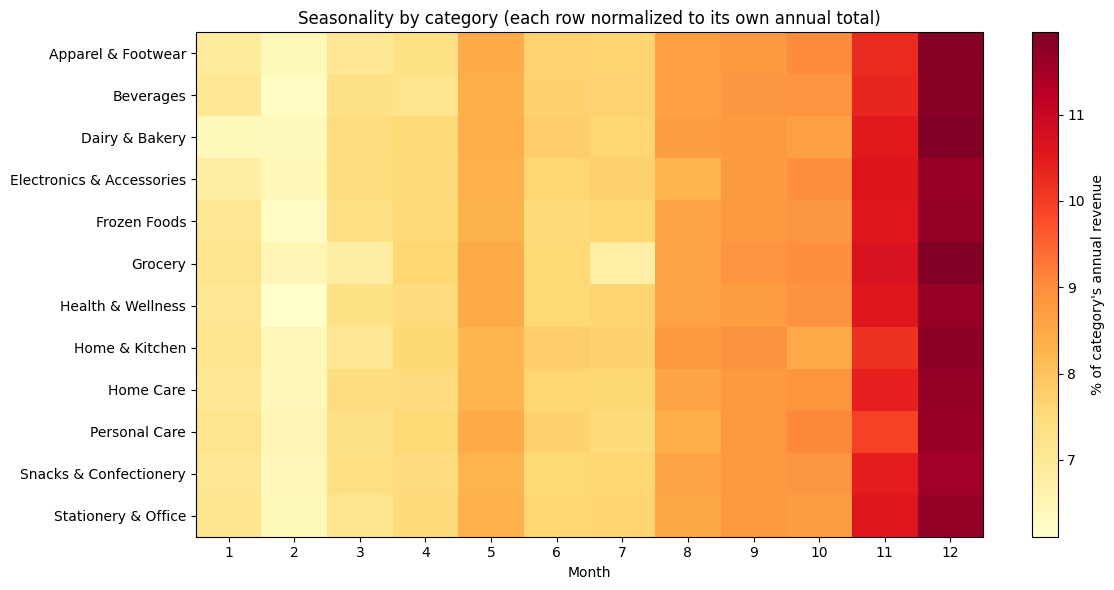

In [41]:
category_summary = (
    daily_sku_final
    .groupby("category", observed=True)
    .agg(total_revenue=("revenue", "sum"), total_units=("units_sold", "sum"))
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
category_summary["revenue_share_pct"] = category_summary["total_revenue"] / category_summary["total_revenue"].sum() * 100
print(category_summary.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(category_summary["category"], category_summary["total_revenue"])
plt.xlabel("Total Revenue (Rs.)")
plt.title("Revenue by Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Does every category peak in Nov/Dec equally, or are some more seasonal than others?
cat_month = (
    daily_sku_final
    .assign(month=daily_sku_final["date"].dt.month)
    .groupby(["category", "month"])["revenue"].sum()
    .unstack("month")
)
cat_month_pct = cat_month.div(cat_month.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
plt.imshow(cat_month_pct, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="% of category's annual revenue")
plt.yticks(range(len(cat_month_pct)), cat_month_pct.index)
plt.xticks(range(12), range(1, 13))
plt.xlabel("Month")
plt.title("Seasonality by category (each row normalized to its own annual total)")
plt.tight_layout()
plt.show()

In [42]:
promotions = pd.read_csv(f"{CONTAMINATED_DIR}/promotions.csv", parse_dates=["start_date", "end_date"])

def get_target_skus(row):
    if row["target_type"] == "All":
        return set(sku_master["sku_id"])
    elif row["target_type"] == "SKU":
        return {row["target_value"]}
    elif row["target_type"] == "Category":
        return set(sku_master.loc[sku_master["category"] == row["target_value"], "sku_id"])
    elif row["target_type"] == "Brand":
        return set(sku_master.loc[sku_master["brand"] == row["target_value"], "sku_id"])
    return set()

results = []
for _, promo in promotions.iterrows():
    target_skus = get_target_skus(promo)
    if not target_skus:
        continue
    in_target = daily_sku_final["sku_id"].isin(target_skus)
    during = (daily_sku_final["date"] >= promo["start_date"]) & (daily_sku_final["date"] <= promo["end_date"])

    during_avg = daily_sku_final.loc[in_target & during, "units_sold"].mean()
    outside_avg = daily_sku_final.loc[in_target & ~during, "units_sold"].mean()

    if pd.notna(during_avg) and pd.notna(outside_avg) and outside_avg > 0:
        results.append({
            "promo_id": promo["promo_id"], "promo_type": promo["promo_type"],
            "n_skus_targeted": len(target_skus),
            "lift_pct": (during_avg / outside_avg - 1) * 100,
        })

promo_type_results = pd.DataFrame(results)
print(f"Promotions analyzed: {len(promo_type_results)} of {len(promotions)}")
print("\nAverage lift by promo type:")
print(promo_type_results.groupby("promo_type")["lift_pct"].agg(["mean", "median", "count"]).round(1))

Promotions analyzed: 100 of 100

Average lift by promo type:
                     mean  median  count
promo_type                              
BOGO                  0.3    -1.1     17
Bundle Offer         -2.4    -2.2     23
Clearance            -0.7    -1.1     20
Flat Discount         2.6    -0.4     18
Percentage Discount  -1.7    -2.5     22


In [43]:
category_summary["avg_price_per_unit"] = category_summary["total_revenue"] / category_summary["total_units"]
category_summary["units_rank"] = category_summary["total_units"].rank(ascending=False).astype(int)
category_summary["revenue_rank"] = category_summary["total_revenue"].rank(ascending=False).astype(int)

print(category_summary[["category", "avg_price_per_unit", "revenue_rank", "units_rank"]]
      .sort_values("revenue_rank").to_string(index=False))

print("\nSeasonality spread by category (highest month % minus lowest month %, larger = more seasonal):")
seasonality_spread = (cat_month_pct.max(axis=1) - cat_month_pct.min(axis=1)).sort_values(ascending=False)
print(seasonality_spread.round(1))

                 category  avg_price_per_unit  revenue_rank  units_rank
Electronics & Accessories         1689.126593             1           9
       Apparel & Footwear         1561.882657             2          12
            Personal Care          598.247947             3           1
           Home & Kitchen         1125.825324             4           8
        Health & Wellness          708.155808             5          11
             Frozen Foods          525.396722             6           5
                Home Care          271.621435             7           4
           Dairy & Bakery          204.302040             8           3
                  Grocery          234.253868             9           6
      Stationery & Office          177.561417            10           2
                Beverages          127.641625            11           7
   Snacks & Confectionery          105.085908            12          10

Seasonality spread by category (highest month % minus lowest mo

In [44]:
results_v2 = []
for _, promo in promotions.iterrows():
    target_skus = get_target_skus(promo)
    if not target_skus:
        continue
    in_target = daily_sku_final["sku_id"].isin(target_skus)

    window_days = (promo["end_date"] - promo["start_date"]).days + 1
    pre_start = promo["start_date"] - pd.Timedelta(days=window_days)
    pre_end = promo["start_date"] - pd.Timedelta(days=1)

    during = (daily_sku_final["date"] >= promo["start_date"]) & (daily_sku_final["date"] <= promo["end_date"])
    just_before = (daily_sku_final["date"] >= pre_start) & (daily_sku_final["date"] <= pre_end)

    during_avg = daily_sku_final.loc[in_target & during, "units_sold"].mean()
    before_avg = daily_sku_final.loc[in_target & just_before, "units_sold"].mean()

    if pd.notna(during_avg) and pd.notna(before_avg) and before_avg > 0:
        results_v2.append({
            "promo_id": promo["promo_id"], "promo_type": promo["promo_type"],
            "lift_pct": (during_avg / before_avg - 1) * 100,
        })

promo_v2 = pd.DataFrame(results_v2)
print(f"Promotions with a valid comparison window: {len(promo_v2)} of {len(promotions)}")
print(promo_v2.groupby("promo_type")["lift_pct"].agg(["mean", "median", "count"]).round(1))

Promotions with a valid comparison window: 100 of 100
                     mean  median  count
promo_type                              
BOGO                  3.6     1.4     17
Bundle Offer          4.2     0.9     23
Clearance            -0.3     1.9     20
Flat Discount        -0.4    -1.4     18
Percentage Discount   3.2     0.9     22


In [45]:
import pandas as pd

daily_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_sku_final.parquet")
daily_sku_final["week_start"] = daily_sku_final["date"].dt.to_period("W").dt.start_time

weekly_sku = (
    daily_sku_final
    .groupby(["sku_id", "week_start"], observed=True)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        n_stores_censored=("n_stores_censored", "sum"),
        promo_flag=("promo_flag", "max"),
        category=("category", "first"),
        subcategory=("subcategory", "first"),
        brand=("brand", "first"),
        cost_price=("cost_price", "first"),
        unit_price=("unit_price", "first"),
    )
    .reset_index()
)
print(f"Weekly rows: {len(weekly_sku):,} ({weekly_sku['sku_id'].nunique():,} SKUs)")
weekly_sku.head()

Weekly rows: 1,033,143 (5,000 SKUs)


,sku_id,week_start,units_sold,revenue,n_stores_censored,promo_flag,category,subcategory,brand,cost_price,unit_price
0,SKU00001,2021-12-27,3.0,2440.229980,0,False,Home & Kitchen,Cookware,NutriPlus,619.77,813.41
1,SKU00001,2022-01-03,14.0,11387.740234,0,False,Home & Kitchen,Cookware,NutriPlus,619.77,813.41
2,SKU00001,2022-01-10,29.0,23588.890625,0,False,Home & Kitchen,Cookware,NutriPlus,619.77,813.41
3,SKU00001,2022-01-17,12.0,9760.919922,0,False,Home & Kitchen,Cookware,NutriPlus,619.77,813.41
4,SKU00001,2022-01-24,15.0,12201.150391,0,False,Home & Kitchen,Cookware,NutriPlus,619.77,813.41


In [46]:
all_skus = weekly_sku["sku_id"].unique()
all_weeks = pd.date_range(weekly_sku["week_start"].min(), weekly_sku["week_start"].max(), freq="W-MON")
print(f"{len(all_skus):,} SKUs x {len(all_weeks):,} weeks = {len(all_skus)*len(all_weeks):,} possible rows")
print(f"Actual rows before filling gaps: {len(weekly_sku):,}")

full_grid = pd.MultiIndex.from_product([all_skus, all_weeks], names=["sku_id", "week_start"]).to_frame(index=False)
weekly_sku_full = full_grid.merge(weekly_sku, on=["sku_id", "week_start"], how="left")

for col in ["units_sold", "revenue", "n_stores_censored"]:
    weekly_sku_full[col] = weekly_sku_full[col].fillna(0)
weekly_sku_full["promo_flag"] = weekly_sku_full["promo_flag"].fillna(False)

sku_attrs = weekly_sku.groupby("sku_id", observed=True)[["category","subcategory","brand","cost_price","unit_price"]].first()
weekly_sku_full = weekly_sku_full.drop(columns=["category","subcategory","brand","cost_price","unit_price"]).merge(sku_attrs, on="sku_id", how="left")

print(f"Rows after filling gaps: {len(weekly_sku_full):,}")

5,000 SKUs x 210 weeks = 1,050,000 possible rows
Actual rows before filling gaps: 1,033,143


/tmp/ipykernel_12822/3997744097.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  weekly_sku_full["promo_flag"] = weekly_sku_full["promo_flag"].fillna(False)


Rows after filling gaps: 1,050,000


In [47]:
tiny = pd.DataFrame({
    "sku_id": ["A", "A", "A", "B", "B", "B"],
    "week":   [1, 2, 3, 1, 2, 3],
    "units":  [10, 15, 12, 100, 90, 95],
})
tiny["lag_wrong"] = tiny["units"].shift(1)
tiny["lag_correct"] = tiny.groupby("sku_id")["units"].shift(1)
display(tiny)

,sku_id,week,units,lag_wrong,lag_correct
0,A,1,10,NaN,NaN
1,A,2,15,10.0,10.0
2,A,3,12,15.0,15.0
3,B,1,100,12.0,NaN
4,B,2,90,100.0,100.0
5,B,3,95,90.0,90.0


In [48]:
weekly_sku_full = weekly_sku_full.sort_values(["sku_id", "week_start"]).reset_index(drop=True)

for lag in [1, 2, 4, 8]:
    weekly_sku_full[f"units_lag_{lag}"] = weekly_sku_full.groupby("sku_id", observed=True)["units_sold"].shift(lag)

weekly_sku_full[["sku_id","week_start","units_sold","units_lag_1","units_lag_2","units_lag_4","units_lag_8"]].head(15)

,sku_id,week_start,units_sold,units_lag_1,units_lag_2,units_lag_4,units_lag_8
0,SKU00001,2021-12-27,3.0,NaN,NaN,NaN,NaN
1,SKU00001,2022-01-03,14.0,3.0,NaN,NaN,NaN
2,SKU00001,2022-01-10,29.0,14.0,3.0,NaN,NaN
3,SKU00001,2022-01-17,12.0,29.0,14.0,NaN,NaN
4,SKU00001,2022-01-24,15.0,12.0,29.0,3.0,NaN
5,SKU00001,2022-01-31,13.0,15.0,12.0,14.0,NaN
6,SKU00001,2022-02-07,28.0,13.0,15.0,29.0,NaN
7,SKU00001,2022-02-14,29.0,28.0,13.0,12.0,NaN
8,SKU00001,2022-02-21,5.0,29.0,28.0,15.0,3.0
9,SKU00001,2022-02-28,32.0,5.0,29.0,13.0,14.0


In [49]:
sample_sku = weekly_sku_full["sku_id"].iloc[0]
check = weekly_sku_full[weekly_sku_full["sku_id"] == sample_sku].head(10)
print(f"Checking {sample_sku} - units_lag_1 should equal the row directly above's units_sold:")
check[["week_start", "units_sold", "units_lag_1"]]

Checking SKU00001 - units_lag_1 should equal the row directly above's units_sold:


,week_start,units_sold,units_lag_1
0,2021-12-27,3.0,NaN
1,2022-01-03,14.0,3.0
2,2022-01-10,29.0,14.0
3,2022-01-17,12.0,29.0
4,2022-01-24,15.0,12.0
5,2022-01-31,13.0,15.0
6,2022-02-07,28.0,13.0
7,2022-02-14,29.0,28.0
8,2022-02-21,5.0,29.0
9,2022-02-28,32.0,5.0


**HERE ONWARDS FEATURE ENGINEERING WILL START**


In [50]:
import pandas as pd
import os

DRIVE_DIR = '/content/drive/MyDrive/foresight_project'
PROCESSED_DIR = f"{DRIVE_DIR}/processed"

# 1. Load Week 1's output
daily_sku_final = pd.read_parquet(f"{PROCESSED_DIR}/daily_sku_final.parquet")
calendar = pd.read_parquet(f"{PROCESSED_DIR}/calendar.parquet")

# 2. Daily -> weekly (the brief asks for a weekly SKU-level forecast)
daily_sku_final["week_start"] = daily_sku_final["date"].dt.to_period("W").dt.start_time
weekly_sku = (
    daily_sku_final.groupby(["sku_id", "week_start"], observed=True)
    .agg(units_sold=("units_sold", "sum"), revenue=("revenue", "sum"),
         n_stores_censored=("n_stores_censored", "sum"), promo_flag=("promo_flag", "max"),
         category=("category", "first"), subcategory=("subcategory", "first"),
         brand=("brand", "first"), cost_price=("cost_price", "first"), unit_price=("unit_price", "first"))
    .reset_index()
)

# 3. Fill genuinely-zero weeks - groupby only makes rows for combinations
#    that actually occurred, so a dead week is missing, not zero, unless
#    the full grid is built explicitly
all_skus = weekly_sku["sku_id"].unique()
all_weeks = pd.date_range(weekly_sku["week_start"].min(), weekly_sku["week_start"].max(), freq="W-MON")
full_grid = pd.MultiIndex.from_product([all_skus, all_weeks], names=["sku_id", "week_start"]).to_frame(index=False)
weekly_sku_full = full_grid.merge(weekly_sku, on=["sku_id", "week_start"], how="left")
for col in ["units_sold", "revenue", "n_stores_censored"]:
    weekly_sku_full[col] = weekly_sku_full[col].fillna(0)
weekly_sku_full["promo_flag"] = weekly_sku_full["promo_flag"].fillna(False)
sku_attrs = weekly_sku.groupby("sku_id", observed=True)[["category","subcategory","brand","cost_price","unit_price"]].first()
weekly_sku_full = weekly_sku_full.drop(columns=["category","subcategory","brand","cost_price","unit_price"]).merge(sku_attrs, on="sku_id", how="left")

# 4. Sort once - every feature below depends on correct order
weekly_sku_full = weekly_sku_full.sort_values(["sku_id", "week_start"]).reset_index(drop=True)

# 5. Lags - grouped by sku_id, so one product's history never bleeds into the next
for lag in [1, 2, 4, 8, 52]:
    weekly_sku_full[f"units_lag_{lag}"] = weekly_sku_full.groupby("sku_id", observed=True)["units_sold"].shift(lag)

# 6. Rolling averages - shift(1) BEFORE rolling, so this week's own value
#    is never included in its own "recent trend" feature
for window in [4, 8]:
    weekly_sku_full[f"units_rolling_mean_{window}"] = weekly_sku_full.groupby("sku_id", observed=True)["units_sold"].transform(lambda x: x.shift(1).rolling(window).mean())
    weekly_sku_full[f"units_rolling_std_{window}"] = weekly_sku_full.groupby("sku_id", observed=True)["units_sold"].transform(lambda x: x.shift(1).rolling(window).std())

# 7. Calendar features - reuse Week 1's table
week_cal = calendar.rename(columns={"date": "week_start"})[["week_start","month","quarter","season","is_holiday"]]
weekly_sku_full = weekly_sku_full.merge(week_cal, on="week_start", how="left")

weekly_sku_full.to_parquet(f"{PROCESSED_DIR}/weekly_sku_features.parquet", index=False)

# ---- Verification ----
print(f"Final table: {len(weekly_sku_full):,} rows, {weekly_sku_full.shape[1]} columns")
print(f"Unmatched calendar joins (want 0): {weekly_sku_full['month'].isna().sum()}")
s = weekly_sku_full[weekly_sku_full["sku_id"] == weekly_sku_full['sku_id'].iloc[0]].head(10).reset_index(drop=True)
lag_ok = s["units_lag_1"].iloc[1] == s["units_sold"].iloc[0]
roll_ok = abs(s["units_sold"].iloc[0:4].mean() - s["units_rolling_mean_4"].iloc[4]) < 0.01
print(f"Lag check: {lag_ok}  |  Rolling check: {roll_ok}")

/tmp/ipykernel_12822/3637595239.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  weekly_sku_full["promo_flag"] = weekly_sku_full["promo_flag"].fillna(False)


Final table: 1,050,000 rows, 24 columns
Unmatched calendar joins (want 0): 5000
Lag check: True  |  Rolling check: True


In [51]:
import numpy as np

def wape(actual, forecast):
    actual, forecast = np.asarray(actual, dtype=float), np.asarray(forecast, dtype=float)
    return np.abs(actual - forecast).sum() / np.abs(actual).sum()

# Hold out the most recent 8 weeks - matches your brief's 6-8 week horizon,
# and previews exactly how Week 3's real backtest will be structured:
# always predicting weeks the "model" hasn't seen, never a random split.
max_week = weekly_sku_full["week_start"].max()
holdout = weekly_sku_full[
    (weekly_sku_full["week_start"] > max_week - pd.Timedelta(weeks=8))
    & weekly_sku_full["units_lag_52"].notna()
].copy()

print(f"Holdout: {holdout['week_start'].min().date()} to {holdout['week_start'].max().date()}, {len(holdout):,} rows")

wape_all = wape(holdout["units_sold"], holdout["units_lag_52"])
print(f"\nSeasonal-naive WAPE, all rows:                {wape_all:.3f}")

clean = holdout[holdout["n_stores_censored"] == 0]
wape_clean = wape(clean["units_sold"], clean["units_lag_52"])
print(f"Seasonal-naive WAPE, excluding censored rows:  {wape_clean:.3f}  ({len(holdout)-len(clean):,} rows excluded)")

Holdout: 2025-11-10 to 2025-12-29, 40,000 rows

Seasonal-naive WAPE, all rows:                0.426
Seasonal-naive WAPE, excluding censored rows:  0.393  (578 rows excluded)


In [52]:
!pip install -q lightgbm

import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib

DRIVE_DIR = '/content/drive/MyDrive/foresight_project'
PROCESSED_DIR = f"{DRIVE_DIR}/processed"

def wape(actual, forecast):
    actual, forecast = np.asarray(actual, dtype=float), np.asarray(forecast, dtype=float)
    return np.abs(actual - forecast).sum() / np.abs(actual).sum()

weekly_sku_features = pd.read_parquet(f"{PROCESSED_DIR}/weekly_sku_features.parquet")

FEATURE_COLS = [
    "units_lag_1", "units_lag_2", "units_lag_4", "units_lag_8", "units_lag_52",
    "units_rolling_mean_4", "units_rolling_mean_8", "units_rolling_std_4", "units_rolling_std_8",
    "month", "quarter", "is_holiday", "promo_flag",
    "category", "subcategory", "brand", "season",
    "cost_price", "unit_price",
]
TARGET_COL = "units_sold"
CAT_COLS = ["category", "subcategory", "brand", "season"]

# Same exclusion logic as the baseline: need full lag history, and drop
# stockout-censored weeks entirely - that's suppressed stock, not real
# demand, and training on it would teach the wrong lesson (see Week 1).
model_ready = weekly_sku_features[
    weekly_sku_features["units_lag_52"].notna() & (weekly_sku_features["n_stores_censored"] == 0)
].copy()
for c in CAT_COLS:
    model_ready[c] = model_ready[c].astype("category")
model_ready["is_holiday"] = model_ready["is_holiday"].astype(int)
model_ready["promo_flag"] = model_ready["promo_flag"].astype(int)
print(f"Model-ready rows: {len(model_ready):,} of {len(weekly_sku_features):,}")

max_week = model_ready["week_start"].max()
fold_results, fold_predictions = [], {}

for fold in range(3):
    test_end = max_week - pd.Timedelta(weeks=8 * fold)
    test_start = test_end - pd.Timedelta(weeks=7)
    train_cutoff = test_start - pd.Timedelta(weeks=1)

    train = model_ready[model_ready["week_start"] <= train_cutoff]
    test = model_ready[(model_ready["week_start"] >= test_start) & (model_ready["week_start"] <= test_end)].copy()
    if len(train) == 0 or len(test) == 0:
        continue

    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1)
    model.fit(train[FEATURE_COLS], train[TARGET_COL], categorical_feature=CAT_COLS)

    preds = np.clip(model.predict(test[FEATURE_COLS]), 0, None)
    test["predicted_units"] = preds
    fold_predictions[fold] = test

    model_wape = wape(test[TARGET_COL], preds)
    baseline_wape = wape(test[TARGET_COL], test["units_lag_52"])
    fold_results.append({
        "fold": fold + 1, "test_start": test_start.date(), "test_end": test_end.date(),
        "n_rows": len(test), "model_wape": round(model_wape, 3), "baseline_wape": round(baseline_wape, 3),
        "improvement_pct": round((baseline_wape - model_wape) / baseline_wape * 100, 1),
    })

results_df = pd.DataFrame(fold_results)
print("\n" + results_df.to_string(index=False))
print(f"\nFold 1 is the exact window your seasonal-naive baseline scored 0.393 on:")
print(f"  Model WAPE this run: {fold_results[0]['model_wape']:.3f}")

# Train the deployable version on ALL available data - this is what
# Streamlit/the scoring service will actually load and use.
final_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1)
final_model.fit(model_ready[FEATURE_COLS], model_ready[TARGET_COL], categorical_feature=CAT_COLS)
joblib.dump(final_model, f"{PROCESSED_DIR}/demand_forecast_model.pkl")

importance = pd.Series(final_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 8 features driving the model:")
print(importance.head(8))
print("\nSaved: demand_forecast_model.pkl")

Model-ready rows: 789,232 of 1,050,000

 fold test_start   test_end  n_rows  model_wape  baseline_wape  improvement_pct
    1 2025-11-10 2025-12-29   39422       0.354          0.393              9.9
    2 2025-09-15 2025-11-03   39810       0.279          0.361             22.8
    3 2025-07-21 2025-09-08   40000       0.264          0.351             24.7

Fold 1 is the exact window your seasonal-naive baseline scored 0.393 on:
  Model WAPE this run: 0.354

Top 8 features driving the model:
units_lag_52            1583
month                   1436
units_lag_8             1408
units_lag_1             1054
units_lag_2              956
units_lag_4              863
units_rolling_mean_8     444
units_rolling_mean_4     231
dtype: int32

Saved: demand_forecast_model.pkl


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

CONTAMINATED_DIR = f"{DRIVE_DIR}/retail_data/retail_contaminated_dataset"
LEAD_TIME_WEEKS = 2             # ~14 days - documented assumption; on_order_units/
                                 # lead_time_days weren't in this dataset (Week 1 report)
OVERSTOCK_WEEKS_THRESHOLD = 16  # more than double a generous 8-week supply target

recent_predictions = fold_predictions[0]
expected_weekly_demand = recent_predictions.groupby("sku_id")["predicted_units"].mean().rename("expected_weekly_demand")

inventory_snapshot = pd.read_csv(f"{CONTAMINATED_DIR}/inventory_snapshot.csv")
inv_sku = inventory_snapshot.groupby("sku_id", as_index=False).agg(
    total_stock_on_hand=("stock_on_hand", "sum"),
    total_safety_stock=("safety_stock", "sum"),
    total_reorder_point=("reorder_point", "sum"),
)

risk_table = inv_sku.merge(expected_weekly_demand, on="sku_id", how="left")
risk_table["expected_weekly_demand"] = risk_table["expected_weekly_demand"].fillna(0)

# Stockout risk: will stock fall below the safety buffer within the lead time?
risk_table["expected_demand_over_lead_time"] = risk_table["expected_weekly_demand"] * LEAD_TIME_WEEKS
risk_table["projected_stock_after_lead_time"] = risk_table["total_stock_on_hand"] - risk_table["expected_demand_over_lead_time"]
risk_table["stockout_risk"] = risk_table["projected_stock_after_lead_time"] < risk_table["total_safety_stock"]

# Overstock risk: units-based, per Week 2's finding - how many weeks would
# current stock take to sell through at the expected rate?
risk_table["weeks_of_stock_on_hand"] = risk_table["total_stock_on_hand"] / risk_table["expected_weekly_demand"].replace(0, np.nan)
risk_table["overstock_risk"] = risk_table["weeks_of_stock_on_hand"] > OVERSTOCK_WEEKS_THRESHOLD
risk_table.loc[risk_table["expected_weekly_demand"] == 0, "overstock_risk"] = risk_table["total_stock_on_hand"] > 0

def classify(row):
    if row["stockout_risk"] and row["overstock_risk"]:
        return "Watch/volatile"
    elif row["stockout_risk"]:
        return "Reorder now"
    elif row["overstock_risk"]:
        return "Markdown/clear"
    return "Healthy"

risk_table["decision"] = risk_table.apply(classify, axis=1)
print("Decision breakdown:")
print(risk_table["decision"].value_counts())

# Validate against Week 1's ground-truth answer key
flags = pd.read_csv(f"{CONTAMINATED_DIR}/sku_inventory_flags.csv")
risk_table["true_stockout"] = risk_table["sku_id"].isin(flags.loc[flags["flag"]=="STOCKOUT_RISK","sku_id"])
risk_table["true_slowmover"] = risk_table["sku_id"].isin(flags.loc[flags["flag"]=="SLOW_MOVER","sku_id"])

print("\nSTOCKOUT_RISK detection vs. ground truth:")
for name, fn in [("Precision", precision_score), ("Recall", recall_score), ("F1", f1_score)]:
    print(f"  {name}: {fn(risk_table['true_stockout'], risk_table['stockout_risk'], zero_division=0):.3f}")

print("\nOVERSTOCK (SLOW_MOVER) detection vs. ground truth:")
for name, fn in [("Precision", precision_score), ("Recall", recall_score), ("F1", f1_score)]:
    print(f"  {name}: {fn(risk_table['true_slowmover'], risk_table['overstock_risk'], zero_division=0):.3f}")

risk_table.to_parquet(f"{PROCESSED_DIR}/risk_scores.parquet", index=False)
print(f"\nSaved risk_scores.parquet - {len(risk_table):,} SKUs")

Decision breakdown:
decision
Markdown/clear    1863
Healthy           1845
Reorder now        787
Name: count, dtype: int64

STOCKOUT_RISK detection vs. ground truth:
  Precision: 0.254
  Recall: 1.000
  F1: 0.405

OVERSTOCK (SLOW_MOVER) detection vs. ground truth:
  Precision: 0.215
  Recall: 1.000
  F1: 0.354

Saved risk_scores.parquet - 4,495 SKUs


In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score
from itertools import product

def classify(row):
    if row["stockout_risk"] and row["overstock_risk"]: return "Watch/volatile"
    elif row["stockout_risk"]: return "Reorder now"
    elif row["overstock_risk"]: return "Markdown/clear"
    return "Healthy"

def score(t, lead_wk, margin, over_wk):
    t = t.copy()
    t["projected_stock"] = t["total_stock_on_hand"] - t["expected_weekly_demand"] * lead_wk
    t["stockout_risk"] = t["projected_stock"] < (t["total_safety_stock"] * margin)
    t["weeks_of_stock_on_hand"] = t["total_stock_on_hand"] / t["expected_weekly_demand"].replace(0, np.nan)
    t["overstock_risk"] = t["weeks_of_stock_on_hand"] > over_wk
    t.loc[t["expected_weekly_demand"] == 0, "overstock_risk"] = t["total_stock_on_hand"] > 0
    return t

best_s, best_s_f1, best_o, best_o_f1 = None, -1, None, -1
for lead_wk, margin, over_wk in product([1,2,3], [0.25,0.5,0.75,1.0], [12,16,20,26,32,40]):
    t = score(risk_table, lead_wk, margin, over_wk)
    s_f1 = f1_score(t["true_stockout"], t["stockout_risk"], zero_division=0)
    o_f1 = f1_score(t["true_slowmover"], t["overstock_risk"], zero_division=0)
    if s_f1 > best_s_f1: best_s_f1, best_s = s_f1, (lead_wk, margin)
    if o_f1 > best_o_f1: best_o_f1, best_o = o_f1, over_wk

risk_table = score(risk_table, best_s[0], best_s[1], best_o)
risk_table["decision"] = risk_table.apply(classify, axis=1)

print(f"Selected: lead_time={best_s[0]}wk, safety_margin={best_s[1]}, overstock_threshold={best_o}wk")
print(f"STOCKOUT precision={precision_score(risk_table['true_stockout'], risk_table['stockout_risk'], zero_division=0):.3f}, "
      f"recall={recall_score(risk_table['true_stockout'], risk_table['stockout_risk'], zero_division=0):.3f}")
print(f"OVERSTOCK precision={precision_score(risk_table['true_slowmover'], risk_table['overstock_risk'], zero_division=0):.3f}, "
      f"recall={recall_score(risk_table['true_slowmover'], risk_table['overstock_risk'], zero_division=0):.3f}")
print(risk_table["decision"].value_counts())

risk_table.to_parquet(f"{PROCESSED_DIR}/risk_scores.parquet", index=False)

forecast_display = fold_predictions[0][["sku_id","week_start","units_sold","predicted_units"]].copy()
forecast_display.to_parquet(f"{PROCESSED_DIR}/forecast_vs_actual.parquet", index=False)
print("Saved risk_scores.parquet and forecast_vs_actual.parquet")

Selected: lead_time=1wk, safety_margin=0.25, overstock_threshold=40wk
STOCKOUT precision=0.482, recall=0.955
OVERSTOCK precision=0.566, recall=1.000
decision
Healthy           3392
Markdown/clear     707
Reorder now        396
Name: count, dtype: int64
Saved risk_scores.parquet and forecast_vs_actual.parquet


In [55]:
CLEAN_DIR = f"{DRIVE_DIR}/retail_data/retail_clean_dataset"

flags = pd.read_csv(f"{CONTAMINATED_DIR}/sku_inventory_flags.csv", parse_dates=["window_start","window_end"])

# ---- Lost sales from stockouts: exact, not estimated ----
stockouts = flags[flags["flag"]=="STOCKOUT_RISK"].copy()
stockouts["stores"] = stockouts["affected_stores"].str.split(";")
windows = stockouts.explode("stores").rename(columns={"stores":"store_id"})
windows["store_id"] = windows["store_id"].str.strip()

lost_sales_total, lost_sales_by_sku = 0, {}
for chunk in pd.read_csv(f"{CLEAN_DIR}/sales_transactions.csv",
                          usecols=["date","store_id","sku_id","total_value"],
                          parse_dates=["date"], chunksize=1_000_000):
    merged = chunk.merge(windows[["sku_id","store_id","window_start","window_end"]], on=["sku_id","store_id"], how="inner")
    if len(merged):
        hit = merged[(merged["date"] >= merged["window_start"]) & (merged["date"] <= merged["window_end"])]
        if len(hit):
            lost_sales_total += hit["total_value"].sum()
            for sku, val in hit.groupby("sku_id")["total_value"].sum().items():
                lost_sales_by_sku[sku] = lost_sales_by_sku.get(sku, 0) + val

print(f"Total lost sales from stockouts: Rs. {lost_sales_total:,.0f}")
lost_sales_df = pd.Series(lost_sales_by_sku, name="lost_sales_rs").sort_values(ascending=False).reset_index()
lost_sales_df.columns = ["sku_id", "lost_sales_rs"]
print(lost_sales_df.head(5))
lost_sales_df.to_parquet(f"{PROCESSED_DIR}/lost_sales_by_sku.parquet", index=False)

# ---- Capital locked in overstock: units above reorder point, at cost ----
slowmovers = flags[flags["flag"]=="SLOW_MOVER"].copy()
slowmovers["stores"] = slowmovers["affected_stores"].str.split(";")
sm_exploded = slowmovers.explode("stores").rename(columns={"stores":"store_id"})
sm_exploded["store_id"] = sm_exploded["store_id"].str.strip()

inventory_snapshot = pd.read_csv(f"{CONTAMINATED_DIR}/inventory_snapshot.csv")
sku_master = pd.read_csv(f"{CONTAMINATED_DIR}/sku_master.csv")

sm_inv = sm_exploded[["sku_id","store_id"]].merge(inventory_snapshot, on=["sku_id","store_id"], how="left") \
                                            .merge(sku_master[["sku_id","cost_price"]], on="sku_id", how="left")
sm_inv["excess_units"] = (sm_inv["stock_on_hand"] - sm_inv["reorder_point"]).clip(lower=0)
sm_inv["capital_locked_rs"] = sm_inv["excess_units"] * sm_inv["cost_price"]

capital_locked_total = sm_inv["capital_locked_rs"].sum()
print(f"\nTotal capital locked in overstock: Rs. {capital_locked_total:,.0f}")
capital_by_sku = sm_inv.groupby("sku_id", as_index=False)["capital_locked_rs"].sum().sort_values("capital_locked_rs", ascending=False)
print(capital_by_sku.head(5))
capital_by_sku.to_parquet(f"{PROCESSED_DIR}/capital_locked_by_sku.parquet", index=False)

print("\n" + "="*50 + "\nBUSINESS IMPACT SUMMARY\n" + "="*50)
print(f"Sales at risk from stockouts:  Rs. {lost_sales_total:,.0f}")
print(f"Capital locked in overstock:   Rs. {capital_locked_total:,.0f}")
print(f"Combined inventory problem:    Rs. {lost_sales_total + capital_locked_total:,.0f}")

Total lost sales from stockouts: Rs. 32,257,801
     sku_id  lost_sales_rs
0  SKU04321    10834812.30
1  SKU03727     1943288.10
2  SKU01371     1023365.61
3  SKU01189      892784.69
4  SKU00728      856930.93

Total capital locked in overstock: Rs. 799,172,105
       sku_id  capital_locked_rs
242  SKU03043        17843738.16
250  SKU03150        15983989.36
4    SKU00075        11779379.62
112  SKU01423        11557845.12
278  SKU03491        11353789.32

BUSINESS IMPACT SUMMARY
Sales at risk from stockouts:  Rs. 32,257,801
Capital locked in overstock:   Rs. 799,172,105
Combined inventory problem:    Rs. 831,429,906
